# Seed Transactions Evolution: WHU vs. Non-WHU
This notebook visualizes how the number of **Seed funding transactions** has evolved over the years (2012–2025), with a clear highlight of the **WHU founders' share**.


## 1. Import Required Libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np


## 2. Load and Inspect Data
The year column is stored as `Unnamed: 0`. Key columns for this analysis are:
- `Seed Transactions` — total seed deals in a given year
- `Seed WHU Transactions` — seed deals by WHU-founded firms (subset of above)


In [2]:
df = pd.read_excel("funding_type_transactions_merged.xlsx")

# Rename the year column for clarity
df = df.rename(columns={"Unnamed: 0": "Year"})

print("Shape:", df.shape)
df[["Year", "Seed Transactions", "Seed WHU Transactions"]].head(14)


Shape: (14, 53)


,Year,Seed Transactions,Seed WHU Transactions
0,2012,183,11
1,2013,268,12
2,2014,302,19
3,2015,418,30
4,2016,380,24
5,2017,333,25
6,2018,375,16
7,2019,297,20
8,2020,316,18
9,2021,490,22


## 3. Prepare Seed Transactions Data
Compute the **non-WHU** count and the **WHU share (%)** per year.


In [3]:
seed = df[["Year", "Seed Transactions", "Seed WHU Transactions"]].copy()
seed["Year"] = seed["Year"].astype(int)

# Non-WHU = total minus WHU
seed["Seed Non-WHU Transactions"] = seed["Seed Transactions"] - seed["Seed WHU Transactions"]

# WHU share as a percentage of total
seed["WHU Share (%)"] = (seed["Seed WHU Transactions"] / seed["Seed Transactions"] * 100).round(1)

seed = seed.sort_values("Year").reset_index(drop=True)
seed


,Year,Seed Transactions,Seed WHU Transactions,Seed Non-WHU Transactions,WHU Share (%)
0,2012,183,11,172,6.0
1,2013,268,12,256,4.5
2,2014,302,19,283,6.3
3,2015,418,30,388,7.2
4,2016,380,24,356,6.3
5,2017,333,25,308,7.5
6,2018,375,16,359,4.3
7,2019,297,20,277,6.7
8,2020,316,18,298,5.7
9,2021,490,22,468,4.5


## 4. Visualize: Seed Transactions Evolution with WHU Share
Stacked bars show total seed deals split between **WHU-founded firms** (highlighted) and the rest of the market. The blue line tracks the **WHU share (%)** on the right-hand axis.


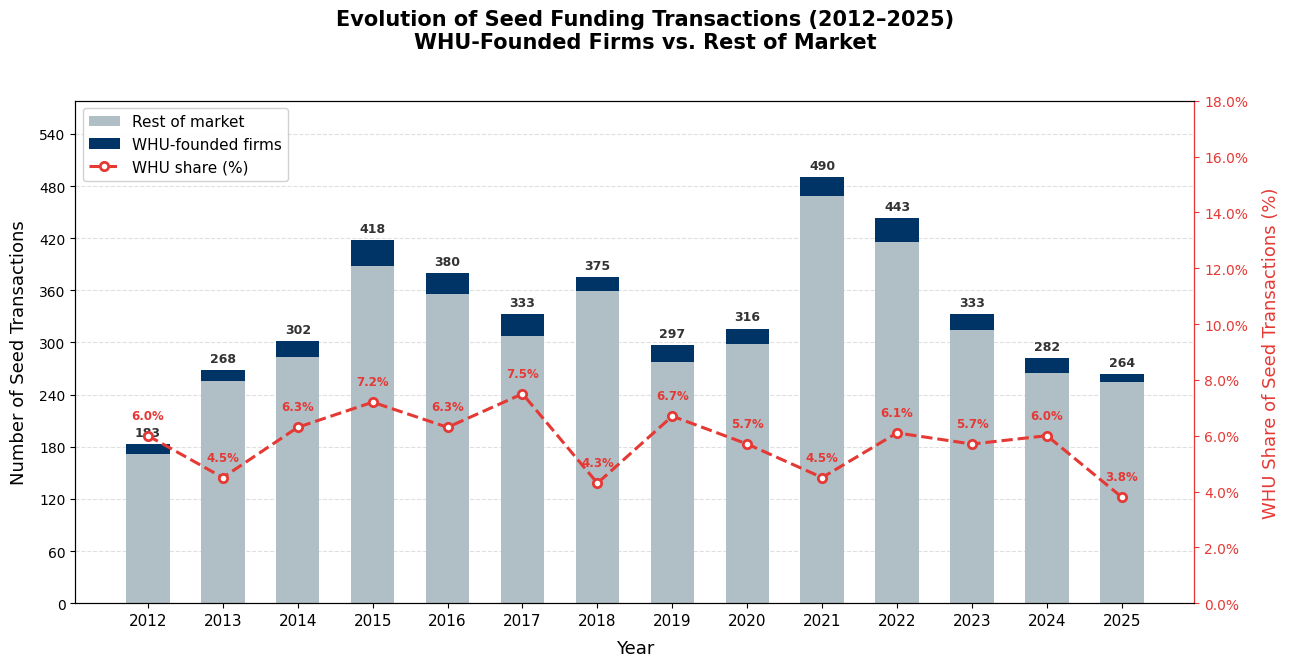

Chart saved as seed_transactions_evolution.png


In [4]:
# ── Colour palette ────────────────────────────────────────────────────────────
COLOR_MARKET = "#B0BEC5"   # light grey-blue  → rest of market
COLOR_WHU    = "#003366"   # deep WHU navy    → WHU transactions
COLOR_LINE   = "#E53935"   # vivid red        → WHU share line

# ── Figure setup ──────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 6.5))

years    = seed["Year"]
x        = np.arange(len(years))
bar_w    = 0.58

# ── Stacked bars ──────────────────────────────────────────────────────────────
bars_market = ax1.bar(
    x, seed["Seed Non-WHU Transactions"],
    width=bar_w, color=COLOR_MARKET,
    label="Rest of market", zorder=2
)
bars_whu = ax1.bar(
    x, seed["Seed WHU Transactions"],
    bottom=seed["Seed Non-WHU Transactions"],
    width=bar_w, color=COLOR_WHU,
    label="WHU-founded firms", zorder=2
)

# ── WHU share line on secondary axis ──────────────────────────────────────────
ax2 = ax1.twinx()
line, = ax2.plot(
    x, seed["WHU Share (%)"],
    color=COLOR_LINE, linewidth=2.2, marker="o",
    markersize=6, markerfacecolor="white", markeredgewidth=2,
    linestyle="--", label="WHU share (%)", zorder=3
)

# Annotate each share value on the line
for xi, (share, total) in enumerate(zip(seed["WHU Share (%)"], seed["Seed Transactions"])):
    ax2.annotate(
        f"{share:.1f}%",
        xy=(xi, share),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center", va="bottom",
        fontsize=8.5, color=COLOR_LINE, fontweight="bold"
    )

# ── Axes formatting ───────────────────────────────────────────────────────────
ax1.set_xticks(x)
ax1.set_xticklabels(years, fontsize=11)
ax1.set_xlabel("Year", fontsize=13, labelpad=8)
ax1.set_ylabel("Number of Seed Transactions", fontsize=13, labelpad=8)
ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax1.set_ylim(0, seed["Seed Transactions"].max() * 1.18)
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax1.set_axisbelow(True)

ax2.set_ylabel("WHU Share of Seed Transactions (%)", fontsize=13,
               color=COLOR_LINE, labelpad=10)
ax2.tick_params(axis="y", colors=COLOR_LINE)
ax2.spines["right"].set_edgecolor(COLOR_LINE)
ax2.set_ylim(0, max(seed["WHU Share (%)"].max() * 2.4, 6))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))

# ── Total labels on top of each combined bar ──────────────────────────────────
for xi, total in enumerate(seed["Seed Transactions"]):
    ax1.text(
        xi, total + seed["Seed Transactions"].max() * 0.012,
        f"{int(total):,}",
        ha="center", va="bottom", fontsize=9, color="#333333", fontweight="bold"
    )

# ── Legend ────────────────────────────────────────────────────────────────────
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles1 + handles2, labels1 + labels2,
    loc="upper left", fontsize=11, framealpha=0.9
)

# ── Title & final touches ─────────────────────────────────────────────────────
fig.suptitle(
    "Evolution of Seed Funding Transactions (2012–2025)\nWHU-Founded Firms vs. Rest of Market",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("seed_transactions_evolution.png", dpi=180, bbox_inches="tight")
plt.show()
print("Chart saved as seed_transactions_evolution.png")


---

## 5. Average Funding Raised: WHU vs. Non-WHU Companies by Funding Type

This section loads `funding_type_money_merged.xlsx` and combines it with the transaction-count data to compute the **average deal size** per funding round for WHU-founded firms and for the rest of the market, across the selected funding types.

$$\text{Avg deal size} = \frac{\text{Total money raised}}{\text{Number of transactions}}$$


In [5]:
# ── Funding types to analyse ──────────────────────────────────────────────────
TYPES = [
    "Pre-Seed", "Seed",
    "Series A", "Series B", "Series C", "Series D",
    "Series E", "Series F", "Series G", "Series H",
    "Venture - Series Unknown", "Funding Round",
]

# ── Load money file ───────────────────────────────────────────────────────────
money = pd.read_excel("funding_type_money_merged.xlsx").rename(columns={"Unnamed: 0": "Year"})

# ── Load transactions file (provides deal counts) ─────────────────────────────
txn = pd.read_excel("funding_type_transactions_merged.xlsx").rename(columns={"Unnamed: 0": "Year"})

# ── Build a tidy summary per funding type ─────────────────────────────────────
rows = []
for t in TYPES:
    m_total   = money[f"{t} Money Raised (in USD)"].fillna(0)
    m_whu     = money[f"{t} WHU Money Raised (in USD)"].fillna(0)
    n_total   = txn[f"{t} Transactions"].fillna(0)
    n_whu     = txn[f"{t} WHU Transactions"].fillna(0)

    # Aggregate across all years
    M_tot  = m_total.sum()
    M_whu  = m_whu.sum()
    N_tot  = n_total.sum()
    N_whu  = n_whu.sum()
    N_nonw = N_tot - N_whu
    M_nonw = M_tot - M_whu

    avg_whu  = (M_whu  / N_whu)  / 1e6 if N_whu  > 0 else np.nan   # in $ M
    avg_nonw = (M_nonw / N_nonw) / 1e6 if N_nonw > 0 else np.nan

    rows.append({"Funding Type": t, "Group": "WHU companies",     "Avg Deal Size ($M)": avg_whu})
    rows.append({"Funding Type": t, "Group": "Non-WHU companies", "Avg Deal Size ($M)": avg_nonw})

avg_df = pd.DataFrame(rows)

# ── Sort funding types by the non-WHU average for a logical axis order ────────
order = (
    avg_df[avg_df["Group"] == "Non-WHU companies"]
    .sort_values("Avg Deal Size ($M)")["Funding Type"]
    .tolist()
)
avg_df["Funding Type"] = pd.Categorical(avg_df["Funding Type"], categories=order, ordered=True)
avg_df = avg_df.sort_values("Funding Type")
avg_df


,Funding Type,Group,Avg Deal Size ($M)
0,Pre-Seed,WHU companies,0.854697
1,Pre-Seed,Non-WHU companies,0.708658
2,Seed,WHU companies,1.829177
3,Seed,Non-WHU companies,1.368492
21,Venture - Series Unknown,Non-WHU companies,8.597317
20,Venture - Series Unknown,WHU companies,21.425340
4,Series A,WHU companies,9.530622
5,Series A,Non-WHU companies,9.078508
22,Funding Round,WHU companies,98.075891
23,Funding Round,Non-WHU companies,9.335296


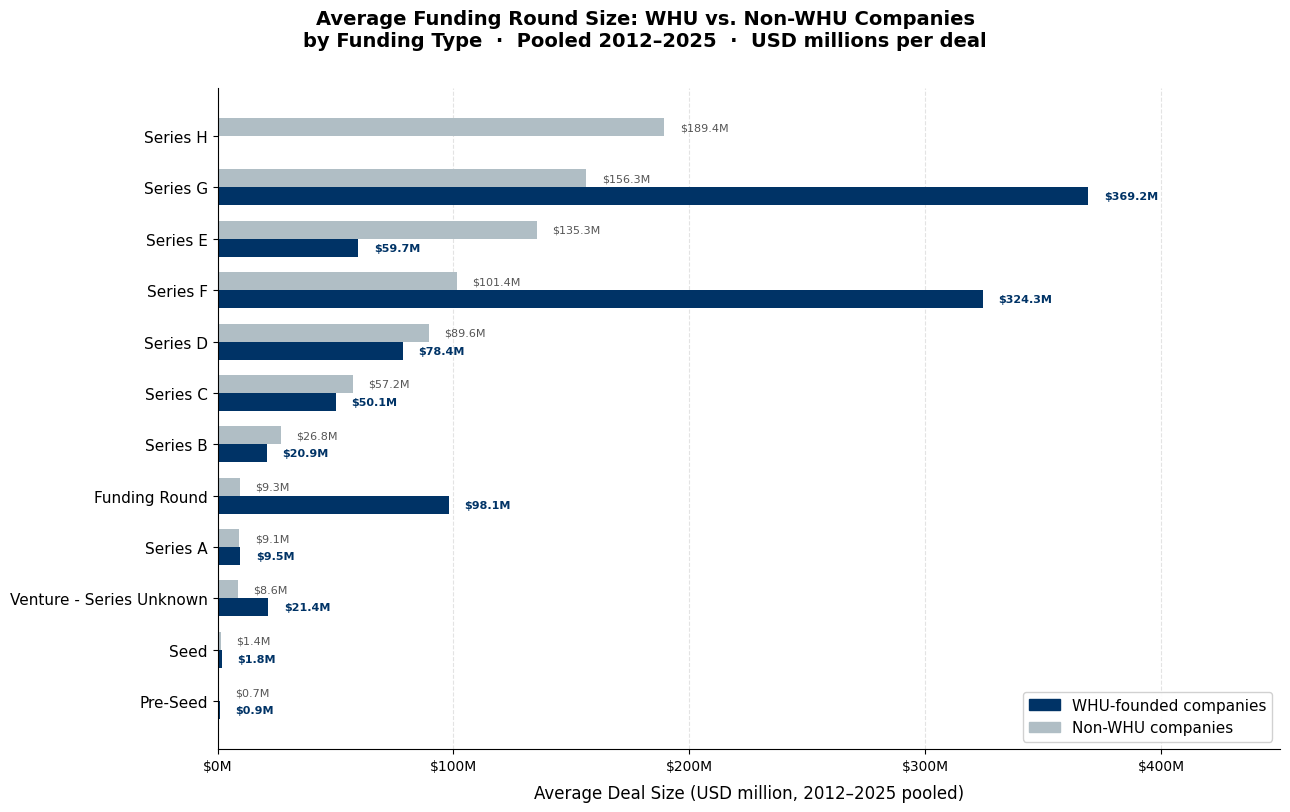

Chart saved as avg_funding_whu_vs_nonwhu.png


In [6]:
import matplotlib.patches as mpatches

COLOR_WHU_BAR  = "#003366"   # deep navy   → WHU
COLOR_NONW_BAR = "#B0BEC5"   # light grey  → non-WHU

fig, ax = plt.subplots(figsize=(13, 8))

n_types = len(order)
y       = np.arange(n_types)
bar_h   = 0.35

whu_vals  = avg_df[avg_df["Group"] == "WHU companies"].set_index("Funding Type").loc[order, "Avg Deal Size ($M)"]
nonw_vals = avg_df[avg_df["Group"] == "Non-WHU companies"].set_index("Funding Type").loc[order, "Avg Deal Size ($M)"]

bars_nonw = ax.barh(y + bar_h / 2, nonw_vals.values, height=bar_h,
                    color=COLOR_NONW_BAR, label="Non-WHU companies", zorder=2)
bars_whu  = ax.barh(y - bar_h / 2, whu_vals.values,  height=bar_h,
                    color=COLOR_WHU_BAR,  label="WHU companies",     zorder=2)

# Compute a fixed label offset (2 % of the max value)
x_max   = max(float(nonw_vals.fillna(0).max()), float(whu_vals.fillna(0).max()))
x_offset = x_max * 0.018

# Annotate bar values
for yi, (vw, vn) in enumerate(zip(whu_vals.values, nonw_vals.values)):
    if not np.isnan(vw) and vw > 0:
        ax.text(vw + x_offset, yi - bar_h / 2,
                f"${vw:.1f}M", va="center", ha="left",
                fontsize=8, color=COLOR_WHU_BAR, fontweight="bold")
    if not np.isnan(vn) and vn > 0:
        ax.text(vn + x_offset, yi + bar_h / 2,
                f"${vn:.1f}M", va="center", ha="left",
                fontsize=8, color="#555555")

# Axes
ax.set_yticks(y)
ax.set_yticklabels(order, fontsize=11)
ax.set_xlabel("Average Deal Size (USD million, 2012–2025 pooled)", fontsize=12, labelpad=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}M"))
ax.set_xlim(0, x_max * 1.22)
ax.grid(axis="x", linestyle="--", alpha=0.35, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

# Legend
whu_patch  = mpatches.Patch(color=COLOR_WHU_BAR,  label="WHU-founded companies")
nonw_patch = mpatches.Patch(color=COLOR_NONW_BAR, label="Non-WHU companies")
ax.legend(handles=[whu_patch, nonw_patch], fontsize=11, loc="lower right", framealpha=0.9)

fig.suptitle(
    "Average Funding Round Size: WHU vs. Non-WHU Companies\n"
    "by Funding Type  ·  Pooled 2012–2025  ·  USD millions per deal",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("avg_funding_whu_vs_nonwhu.png", dpi=180, bbox_inches="tight")
plt.show()
print("Chart saved as avg_funding_whu_vs_nonwhu.png")


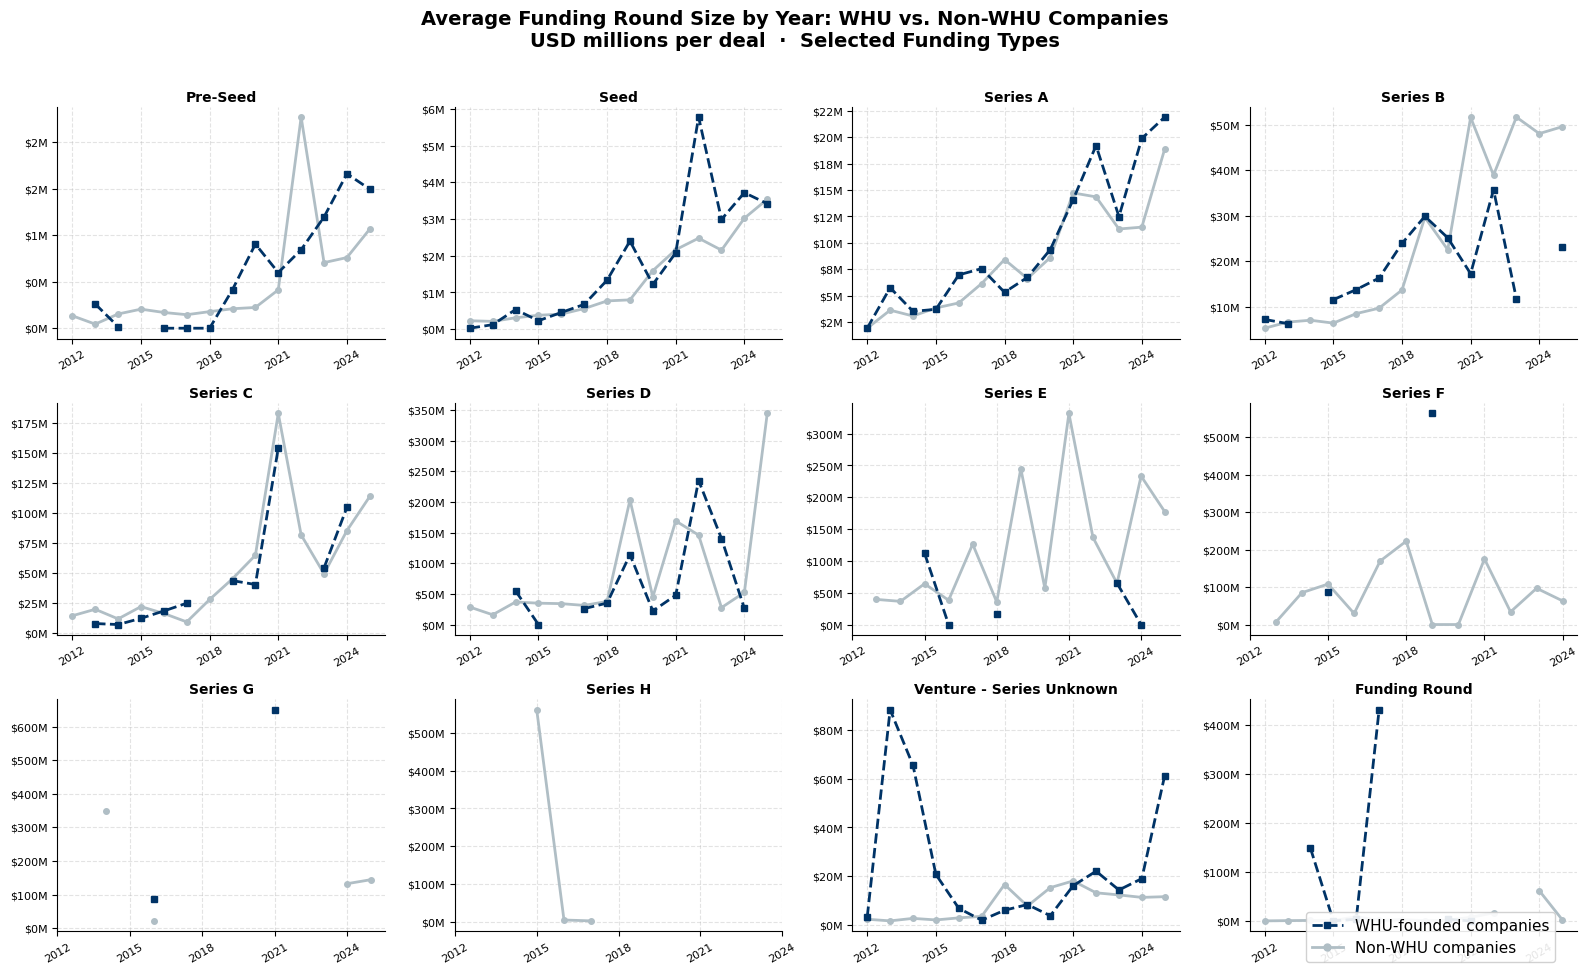

Chart saved as avg_funding_evolution_by_type.png


In [7]:
# ── Year-by-year average deal size per funding type ───────────────────────────
years_list = sorted(money["Year"].astype(int).unique())
yearly_rows = []

for t in TYPES:
    m_total = money[f"{t} Money Raised (in USD)"].fillna(0).values
    m_whu   = money[f"{t} WHU Money Raised (in USD)"].fillna(0).values
    n_total = txn[f"{t} Transactions"].fillna(0).values
    n_whu   = txn[f"{t} WHU Transactions"].fillna(0).values

    for i, yr in enumerate(money["Year"].astype(int).values):
        N_w = n_whu[i];   M_w = m_whu[i]
        N_t = n_total[i]; M_t = m_total[i]
        N_n = N_t - N_w;  M_n = M_t - M_w

        yearly_rows.append({
            "Year": yr, "Funding Type": t,
            "WHU Avg ($M)":    (M_w / N_w / 1e6)  if N_w > 0 else np.nan,
            "Non-WHU Avg ($M)":(M_n / N_n / 1e6)  if N_n > 0 else np.nan,
        })

yearly = pd.DataFrame(yearly_rows).sort_values(["Funding Type", "Year"])

# ── Small-multiples grid ──────────────────────────────────────────────────────
ncols = 4
nrows = int(np.ceil(len(TYPES) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.2), sharey=False)
axes_flat = axes.flatten()

for idx, t in enumerate(TYPES):
    ax = axes_flat[idx]
    sub = yearly[yearly["Funding Type"] == t].set_index("Year")

    ax.plot(sub.index, sub["Non-WHU Avg ($M)"], color=COLOR_NONW_BAR,
            linewidth=2, marker="o", markersize=4, label="Non-WHU")
    ax.plot(sub.index, sub["WHU Avg ($M)"],     color=COLOR_WHU_BAR,
            linewidth=2, marker="s", markersize=4, linestyle="--", label="WHU")

    ax.set_title(t, fontsize=10, fontweight="bold", pad=4)
    ax.set_xticks(years_list[::3])          # show every 3rd year to avoid clutter
    ax.tick_params(axis="x", labelsize=8, rotation=30)
    ax.tick_params(axis="y", labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.0f}M"))
    ax.grid(linestyle="--", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)

# Hide empty panels
for idx in range(len(TYPES), len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Shared legend
whu_line  = plt.Line2D([0], [0], color=COLOR_WHU_BAR,  linewidth=2, linestyle="--",
                        marker="s", markersize=5, label="WHU-founded companies")
nonw_line = plt.Line2D([0], [0], color=COLOR_NONW_BAR, linewidth=2,
                        marker="o", markersize=5, label="Non-WHU companies")
fig.legend(handles=[whu_line, nonw_line], loc="lower right",
           fontsize=11, framealpha=0.9, bbox_to_anchor=(0.98, 0.01))

fig.suptitle(
    "Average Funding Round Size by Year: WHU vs. Non-WHU Companies\n"
    "USD millions per deal  ·  Selected Funding Types",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("avg_funding_evolution_by_type.png", dpi=180, bbox_inches="tight")
plt.show()
print("Chart saved as avg_funding_evolution_by_type.png")


---

## 6. Average Funding per Deal: WHU vs. Non-WHU — Pooled Across All Selected Funding Types

All 12 funding types are combined each year. The average deal size is:

$$\text{Avg deal size}_{\text{group},\,year} = \frac{\sum_{\text{types}} \text{Money Raised}_{\text{group}}}{\sum_{\text{types}} \text{Transactions}_{\text{group}}}$$


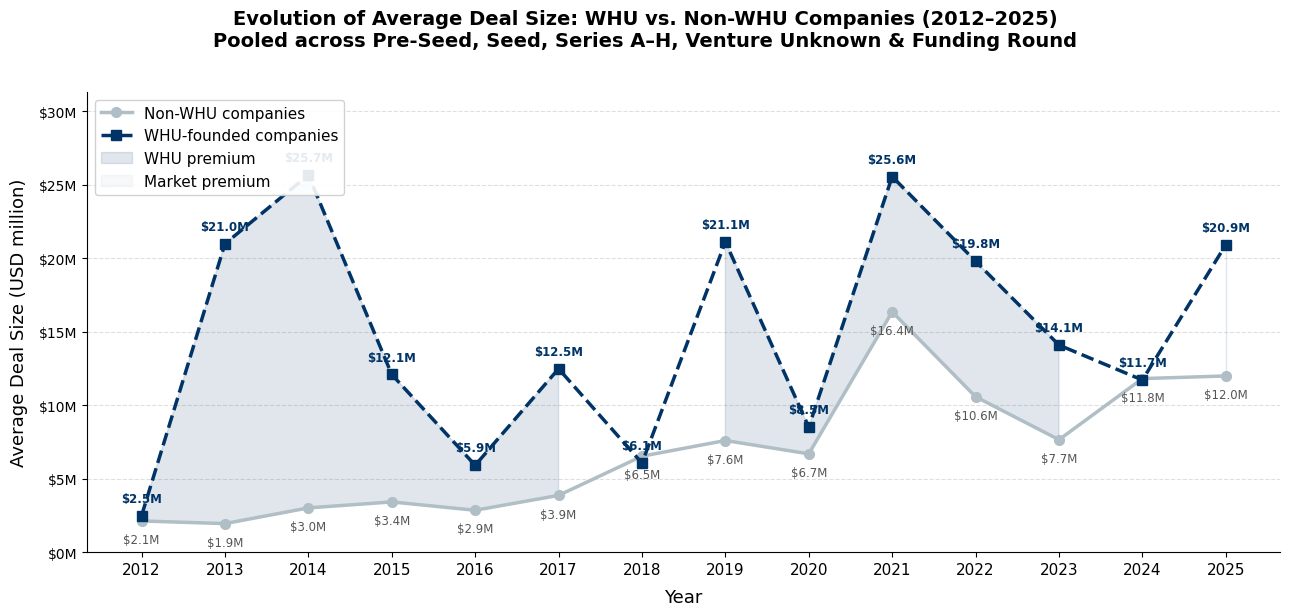

Chart saved as avg_funding_pooled_evolution.png


In [8]:
# ── Pool all 12 funding types per year ────────────────────────────────────────
pooled_rows = []

for yr in sorted(money["Year"].astype(int).unique()):
    yr_money = money[money["Year"] == yr]
    yr_txn   = txn[txn["Year"] == yr]

    M_whu_tot  = sum(float(yr_money[f"{t} WHU Money Raised (in USD)"].fillna(0).iloc[0])   for t in TYPES)
    N_whu_tot  = sum(float(yr_txn[f"{t} WHU Transactions"].fillna(0).iloc[0])              for t in TYPES)
    M_all_tot  = sum(float(yr_money[f"{t} Money Raised (in USD)"].fillna(0).iloc[0])       for t in TYPES)
    N_all_tot  = sum(float(yr_txn[f"{t} Transactions"].fillna(0).iloc[0])                  for t in TYPES)

    M_nonw = M_all_tot - M_whu_tot
    N_nonw = N_all_tot - N_whu_tot

    pooled_rows.append({
        "Year":              yr,
        "WHU Avg ($M)":     (M_whu_tot / N_whu_tot / 1e6) if N_whu_tot > 0 else np.nan,
        "Non-WHU Avg ($M)": (M_nonw    / N_nonw    / 1e6) if N_nonw    > 0 else np.nan,
    })

pooled = pd.DataFrame(pooled_rows).sort_values("Year").reset_index(drop=True)

# ── Visual ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(pooled["Year"], pooled["Non-WHU Avg ($M)"],
        color=COLOR_NONW_BAR, linewidth=2.5, marker="o", markersize=7,
        label="Non-WHU companies")
ax.plot(pooled["Year"], pooled["WHU Avg ($M)"],
        color=COLOR_WHU_BAR, linewidth=2.5, marker="s", markersize=7,
        linestyle="--", label="WHU-founded companies")

# ── Annotate each point ───────────────────────────────────────────────────────
for _, row in pooled.iterrows():
    if not np.isnan(row["WHU Avg ($M)"]):
        ax.annotate(f"${row['WHU Avg ($M)']:.1f}M",
                    xy=(row["Year"], row["WHU Avg ($M)"]),
                    xytext=(0, 10), textcoords="offset points",
                    ha="center", fontsize=8.5,
                    color=COLOR_WHU_BAR, fontweight="bold")
    if not np.isnan(row["Non-WHU Avg ($M)"]):
        ax.annotate(f"${row['Non-WHU Avg ($M)']:.1f}M",
                    xy=(row["Year"], row["Non-WHU Avg ($M)"]),
                    xytext=(0, -16), textcoords="offset points",
                    ha="center", fontsize=8.5,
                    color="#555555")

# ── Shaded gap between the two lines ─────────────────────────────────────────
ax.fill_between(
    pooled["Year"],
    pooled["WHU Avg ($M)"].fillna(0),
    pooled["Non-WHU Avg ($M)"].fillna(0),
    where=(pooled["WHU Avg ($M)"] >= pooled["Non-WHU Avg ($M)"]),
    alpha=0.12, color=COLOR_WHU_BAR, label="WHU premium"
)
ax.fill_between(
    pooled["Year"],
    pooled["WHU Avg ($M)"].fillna(0),
    pooled["Non-WHU Avg ($M)"].fillna(0),
    where=(pooled["WHU Avg ($M)"] < pooled["Non-WHU Avg ($M)"]),
    alpha=0.10, color=COLOR_NONW_BAR, label="Market premium"
)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xticks(pooled["Year"])
ax.set_xticklabels(pooled["Year"], fontsize=11)
ax.set_xlabel("Year", fontsize=13, labelpad=8)
ax.set_ylabel("Average Deal Size (USD million)", fontsize=13, labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.0f}M"))
y_top = max(pooled["WHU Avg ($M)"].max(), pooled["Non-WHU Avg ($M)"].max())
ax.set_ylim(0, y_top * 1.22)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

ax.legend(fontsize=11, loc="upper left", framealpha=0.9)
fig.suptitle(
    "Evolution of Average Deal Size: WHU vs. Non-WHU Companies (2012–2025)\n"
    "Pooled across Pre-Seed, Seed, Series A–H, Venture Unknown & Funding Round",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("avg_funding_pooled_evolution.png", dpi=180, bbox_inches="tight")
plt.show()
print("Chart saved as avg_funding_pooled_evolution.png")
